In [1]:
import pandas as pd

df = pd.read_csv("training_data_202601.csv")
df

,unique_id,Painting,"On a scale of 1–10, how intense is the emotion conveyed by the artwork?",Describe how this painting makes you feel.,This art piece makes me feel sombre.,This art piece makes me feel content.,This art piece makes me feel calm.,This art piece makes me feel uneasy.,How many prominent colours do you notice in this painting?,How many objects caught your eye in the painting?,How much (in Canadian dollars) would you be willing to pay for this painting?,"If you could purchase this painting, which room would you put that painting in?","If you could view this art in person, who would you want to view it with?",What season does this art piece remind you of?,"If this painting was a food, what would be?",Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.
0,1,The Persistence of Memory,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,The Persistence of Memory,5.0,"The clocks are burnt on a hot desert, it embod...",4 - Agree,3 - Neutral/Unsure,2 - Disagree,1 - Strongly disagree,2.0,4.0,0,Bathroom,By yourself,Fall,Fries,A country song that contrasts nostalgia for th...
2,3,The Persistence of Memory,7.0,This painting makes me feel dread. The clock r...,4 - Agree,1 - Strongly disagree,1 - Strongly disagree,4 - Agree,4.0,3.0,$5,"Bathroom,Dining room","Coworkers/Classmates,By yourself",Fall,Sardines,A melancholy instrumental with a monotone voic...
3,4,The Persistence of Memory,7.0,Deflated,4 - Agree,1 - Strongly disagree,2 - Disagree,4 - Agree,10.0,7.0,a,"Bedroom,Bathroom",Coworkers/Classmates,Winter,a,q
4,5,The Persistence of Memory,7.0,The painting gives me a sense of calmness and ...,3 - Neutral/Unsure,4 - Agree,5 - Strongly agree,3 - Neutral/Unsure,4.0,6.0,300 dollars.,Living room,Friends,"Spring,Summer",Churros.,Radiohead's album in rainbows.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,558,The Water Lily Pond,5.0,Joy and relaxation.,2 - Disagree,4 - Agree,4 - Agree,2 - Disagree,2.0,1.0,$35,"Bedroom,Office,Living room,Dining room","Friends,Family members,Coworkers/Classmates,St...",Spring,green apple,nature forest soundtrack
1682,559,The Water Lily Pond,9.0,This painting makes me feel happy,2 - Disagree,5 - Strongly agree,5 - Strongly agree,1 - Strongly disagree,3.0,3.0,200,"Bedroom,Office,Living room",Friends,"Spring,Summer",Salad,Slow guitar soundtrack
1683,560,The Water Lily Pond,8.0,This painting makes me feel warm and new birth...,1 - Strongly disagree,5 - Strongly agree,3 - Neutral/Unsure,1 - Strongly disagree,2.0,2.0,"200 Dollars, pay for the emotion","Bedroom,Living room","Friends,Family members",Spring,Fresh salad,"Various animal sounds, like bird sounds; and l..."
1684,561,The Water Lily Pond,5.0,makes me feel nonchalant,2 - Disagree,2 - Disagree,4 - Agree,1 - Strongly disagree,4.0,1.0,10,"Bathroom,Office","Friends,Family members,Coworkers/Classmates,St...",Spring,apple,simon and garfunkel


In [2]:
df['Painting'].value_counts()

,count
Painting,
The Persistence of Memory,562
The Starry Night,562
The Water Lily Pond,562


In [3]:
# Feature types
# Numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features = [col for col in numerical_features if col != "unique_id"]

# Categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features = [col for col in categorical_features if col != 'Painting']

print("Numerical features:\n", numerical_features)
print("\nCategorical features:\n", categorical_features)

Numerical features:
 ['On a scale of 1–10, how intense is the emotion conveyed by the artwork?', 'How many prominent colours do you notice in this painting?', 'How many objects caught your eye in the painting?']

Categorical features:
 ['Describe how this painting makes you feel.', 'This art piece makes me feel sombre.', 'This art piece makes me feel content.', 'This art piece makes me feel calm.', 'This art piece makes me feel uneasy.', 'How much (in Canadian dollars) would you be willing to pay for this painting?', 'If you could purchase this painting, which room would you put that painting in?', 'If you could view this art in person, who would you want to view it with?', 'What season does this art piece remind you of?', 'If this painting was a food, what would be?', 'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.']


In [10]:
df.isnull().sum()

,0
unique_id,0
Painting,0
"On a scale of 1–10, how intense is the emotion conveyed by the artwork?",65
Describe how this painting makes you feel.,75
This art piece makes me feel sombre.,70
This art piece makes me feel content.,72
This art piece makes me feel calm.,71
This art piece makes me feel uneasy.,71
How many prominent colours do you notice in this painting?,74
How many objects caught your eye in the painting?,74


In [11]:
# Exclude target and id
feature_cols = df.columns.drop(["unique_id", "Painting"])

continuous_features = []
categorical_features = []

for col in feature_cols:
    if df[col].dtype in ["int64", "float64"]:
        continuous_features.append(col)
    else:
        categorical_features.append(col)

print("Continuous features:", len(continuous_features))
print("Categorical features:", len(categorical_features))
print(continuous_features)

Continuous features: 3
Categorical features: 11
['On a scale of 1–10, how intense is the emotion conveyed by the artwork?', 'How many prominent colours do you notice in this painting?', 'How many objects caught your eye in the painting?']


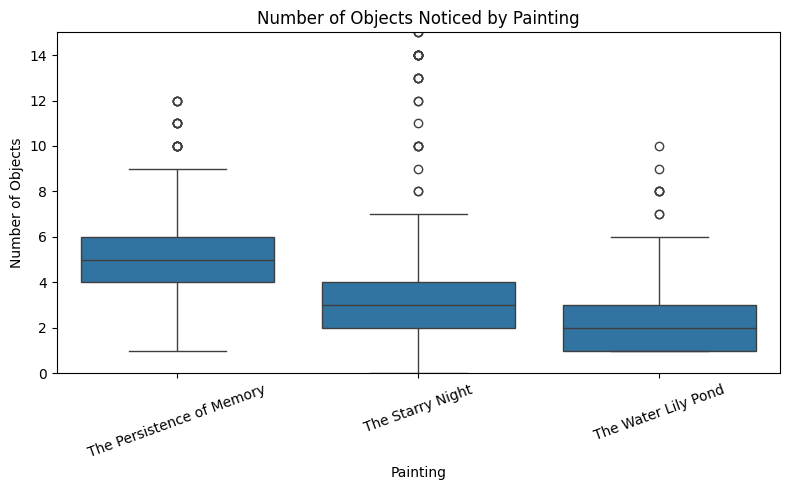

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

objects_col = "How many objects caught your eye in the painting?"

plt.figure(figsize=(8,5))
sns.boxplot(x="Painting", y=objects_col, data=df)

plt.ylim(0, 15)
plt.title("Number of Objects Noticed by Painting")
plt.xlabel("Painting")
plt.ylabel("Number of Objects")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

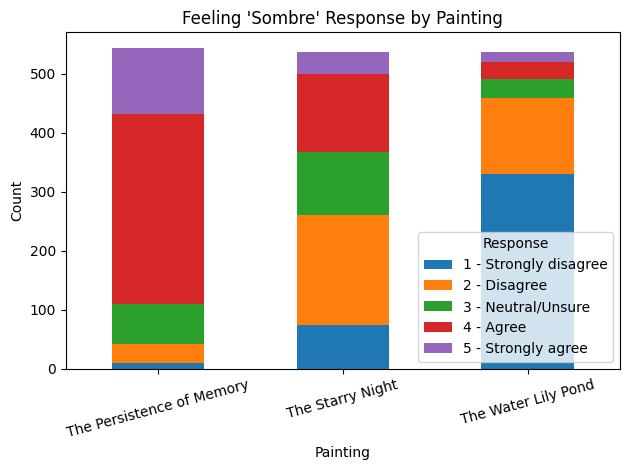

In [16]:
sombre_col = "This art piece makes me feel sombre."

# Create cross-tabulation (counts per painting)
sombre_counts = pd.crosstab(df["Painting"], df[sombre_col])

# Plot stacked bar chart
sombre_counts.plot(kind="bar", stacked=True)

plt.title("Feeling 'Sombre' Response by Painting")
plt.xlabel("Painting")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.legend(title="Response")
plt.tight_layout()
plt.show()
